<a href="https://colab.research.google.com/github/thenovicenafi/MLOps-CreditRisk-MLflow-E2E/blob/main/notebooks/1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [ ]:
!pip install dagshub mlflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.3/261.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 779.2/779.2 kB 44.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/20

In [ ]:
import os
import dagshub
import mlflow

USER_NAME = os.environ.get("DAGSHUB_USER")
REPO_NAME = "MLOps-CreditRisk-MLflow-E2E"

dagshub.init(
    repo_owner=USER_NAME,
    repo_name=REPO_NAME,
    mlflow=True
)

mlflow.set_tracking_uri(
    f"https://dagshub.com/{USER_NAME}/{REPO_NAME}.mlflow"
)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=44823997-4cbc-43a4-9f0a-19923fdaadf7&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=bb14db3f1c7c31c8ed6753782dbf7fb179e7961c32946d1bc5b298d23aa6425d




Accessing as thenovicenafi

Initialized MLflow to track repo "thenovicenafi/MLOps-CreditRisk-MLflow-E2E"

Repository thenovicenafi/MLOps-CreditRisk-MLflow-E2E initialized!

The First EDA

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [ ]:
DATASET_NAME = "creditcard.csv"
RUN_NAME = "eda_preprocessing2"
RANDOM_STATE = 42
TEST_SIZE = 0.2

Files in dataset directory: ['creditcard.csv']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


X_train: (227845, 30)
X_test : (56962, 30)
y_train: (227845,)
y_test : (56962,)
🏃 View run eda_preprocessing2 at: https://dagshub.com/thenovicenafi/MLOps-CreditRisk-MLflow-E2E.mlflow/#/experiments/1/runs/fe6f9fb9c3f24f2c8b8a82c9598529a5
🧪 View experiment at: https://dagshub.com/thenovicenafi/MLOps-CreditRisk-MLflow-E2E.mlflow/#/experiments/1


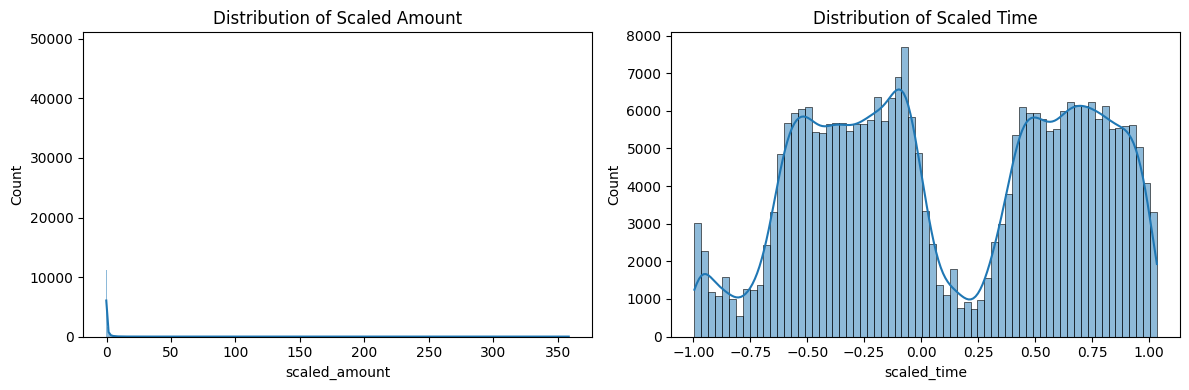

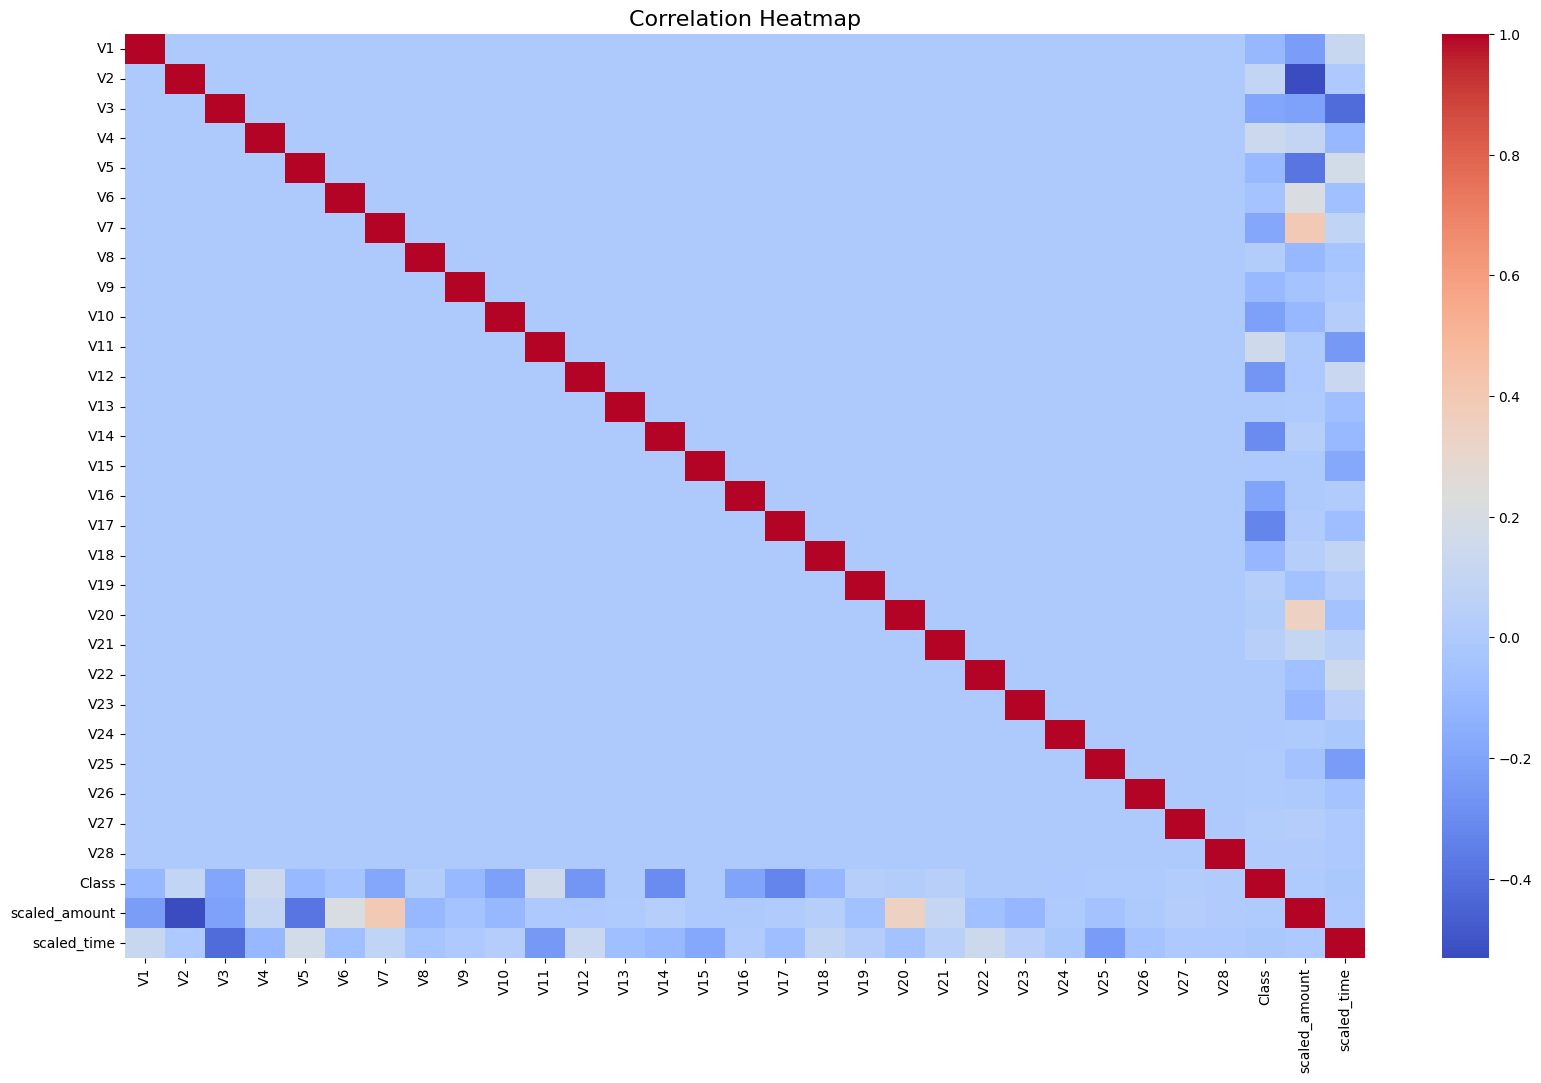

In [ ]:
# START MLFLOW RUN
mlflow.set_experiment("Fraud_EDA")
mlflow.end_run()

with mlflow.start_run(run_name=RUN_NAME):

    # LOAD DATA
    dataset_files = os.listdir(path)
    print(f"Files in dataset directory: {dataset_files}")

    data_file = os.path.join(path, DATASET_NAME)
    df = pd.read_csv(data_file)

    mlflow.log_param("dataset_name", DATASET_NAME)
    mlflow.log_param("n_rows", df.shape[0])
    mlflow.log_param("n_features", df.shape[1])

    print(df.info())
    print("Total missing values:", df.isnull().sum().sum())

    # CLASS DISTRIBUTION (RAW)
    class_counts = df["Class"].value_counts(normalize=True) * 100

    plt.figure(figsize=(6, 6))
    plt.pie(
        class_counts,
        labels=["Normal", "Fraud"],
        autopct="%1.2f%%",
        startangle=90
    )
    plt.title("Class Distribution (Original Dataset)")
    plt.savefig("class_distribution_original.png")
    plt.close()

    mlflow.log_artifact("class_distribution_original.png")

    # SCALING (EDA PURPOSE)
    scaler = RobustScaler()

    df["scaled_amount"] = scaler.fit_transform(df[["Amount"]])
    df["scaled_time"] = scaler.fit_transform(df[["Time"]])

    df.drop(["Time", "Amount"], axis=1, inplace=True)

    mlflow.log_param("scaler", "RobustScaler")
    mlflow.log_param("scaled_features", "Amount, Time")
    mlflow.log_param("scaling_scope", "EDA_full_dataset")

    display(df.head())

    # SCALING (VISUALIZATION)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df['scaled_amount'], ax=ax[0], kde=True)
    ax[0].set_title('Distribution of Scaled Amount')

    sns.histplot(df['scaled_time'], ax=ax[1], kde=True)
    ax[1].set_title('Distribution of Scaled Time')

    plt.tight_layout()
    plt.savefig("scaled_feature_distribution.png")
    mlflow.log_artifact("scaled_feature_distribution.png")

    # TRAIN - TEST SPLIT
    X = df.drop("Class", axis=1)
    y = df["Class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        stratify=y,
        random_state=RANDOM_STATE
    )

    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("stratify", True)
    mlflow.log_param("random_state", RANDOM_STATE)

    print("X_train:", X_train.shape)
    print("X_test :", X_test.shape)
    print("y_train:", y_train.shape)
    print("y_test :", y_test.shape)

    # CLASS DISTRIBUTION
    dist_df = pd.DataFrame({
        "Dataset": ["Train", "Train", "Test", "Test"],
        "Class": ["Normal", "Fraud", "Normal", "Fraud"],
        "Percentage": [
            y_train.value_counts(normalize=True)[0] * 100,
            y_train.value_counts(normalize=True)[1] * 100,
            y_test.value_counts(normalize=True)[0] * 100,
            y_test.value_counts(normalize=True)[1] * 100,
        ],
    })

    plt.figure(figsize=(8, 5))
    sns.barplot(
        data=dist_df,
        x="Dataset",
        y="Percentage",
        hue="Class"
    )
    plt.title("Class Proportion: Train vs Test")
    plt.ylabel("Percentage (%)")
    plt.savefig("train_test_distribution.png")
    plt.close()

    mlflow.log_artifact("train_test_distribution.png")

    # SMOTE (EDA CHECK)
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    mlflow.log_param("imbalance_handling", "SMOTE")
    mlflow.log_param("smote_random_state", RANDOM_STATE)

    smote_dist = pd.Series(y_train_res).value_counts(normalize=True) * 100

    plt.figure(figsize=(6, 6))
    plt.pie(
        smote_dist,
        labels=["Normal", "Fraud"],
        autopct="%1.2f%%",
        startangle=90
    )
    plt.title("After SMOTE (Train Set)")
    plt.savefig("smote_distribution.png")
    plt.close()

    mlflow.log_artifact("smote_distribution.png")

    #HEATMAP CORRELATION
    plt.figure(figsize=(20, 12))
    correlations = df.corr()

    sns.heatmap(correlations, cmap="coolwarm", annot=False)
    plt.title("Correlation Heatmap", fontsize=16)
    plt.savefig("correlation_heatmap.png")
    mlflow.log_artifact("correlation_heatmap.png")

    mlflow.log_param("imbalance_handling", "SMOTE")
    mlflow.log_param("smote_random_state", RANDOM_STATE)